# Lesson 2 - Image classification with CNNs and ResNets

> This notebook is an educational demonstration and does not constitute a medical diagnostic system.

Previously, we saw how a simple network receiving ready-made numeric features could learn to classify tabular data into two classes.

Now we will build networks capable of **learning features directly from pixels** to classify images into four classes.

We first introduce convolutions and convolutional neural networks (CNNs). We then implement a small CNN, study residual connections, and compare transfer learning with ResNet-18 and ResNet-50.

## Why not use only an MLP?

An RGB image with `224 × 224` pixels is represented by:

$$3 \times 224 \times 224 = 150{,}528$$

numeric values, one for every combination of channel, row, and column.

![RGB channels](../../assets/CNN-model-sequentially-identifies-patterns-processes-images.png)

See [Understanding Convolution Neural Network (CNN) Architecture — Deep Learning](https://www.ksolves.com/blog/artificial-intelligence/understanding-convolution-neural-network-architecture).

To receive this image, an MLP would first need to transform it into a single vector with 150,528 elements. This process, called **flattening, explicitly removes the image's spatial organization**: the model no longer knows which pixels were close together, formed an edge, or belonged to the same region.

Furthermore, connecting those 150,528 values to a layer containing only 128 neurons would already require more than **19 million weights**:

$$150{,}528 \times 128 = 19{,}267{,}584$$

A CNN is more suitable because it processes small image regions at a time. Its filters share the same weights across different positions, allowing the network to recognize patterns such as edges, contrasts, and textures regardless of where they appear.

![CNN architecture](../../assets/CNN-Model-Architecture.png)

See [Understanding Convolution Neural Network (CNN) Architecture — Deep Learning](https://www.ksolves.com/blog/artificial-intelligence/understanding-convolution-neural-network-architecture).

Therefore, a CNN:

- better preserves spatial relationships between pixels;
- uses far fewer parameters;
- recognizes the same pattern in different regions;
- combines simple patterns to learn progressively more complex structures.

An MLP can still classify images, but it is generally less efficient and ignores an essential property: **pixel positions and neighborhoods also carry meaning**.

## Convolution

A **kernel** is a small matrix of weights that moves across the image. At each position, it combines pixels from a local region and produces a value in a new feature map:

$$z_{i,j} = \sum_{c,u,v} K_{c,u,v} X_{c,i+u,j+v} + b$$

Kernel weights are learned through backpropagation, just like the weights in an MLP's linear layers. Early layers usually respond to simple patterns, while later layers combine them into more abstract representations.

### ReLU, pooling, and channels

- **ReLU** adds nonlinearity.
- **Pooling** reduces spatial dimensions while preserving important responses.
- **Channels** represent different learned feature maps.
- **Batch normalization** stabilizes activations and facilitates training.

Our CNN increases its channel count from `3 → 16 → 32 → 64` while reducing height and width.

### Further reading

For a visual and intuitive explanation of CNNs, see:

- [But what is a convolution? — 3Blue1Brown](https://www.youtube.com/watch?v=KuXjwB4LzSA)

## Libraries, seed, and device

In [1]:
from copy import deepcopy
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights, ResNet50_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
print("CUDA:", torch.version.cuda)

PyTorch: 2.13.0+cu132
Device: cuda
CUDA: 13.2


## Prepared manifest

The [`01-prepare-images.en.ipynb`](01-prepare-images.en.ipynb) notebook created a manifest containing paths, labels, and splits. The test set is already defined but is used only during final evaluation.

In [2]:
def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Project root not found.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_PATH = DATA_DIR / "alzheimer_mri_manifest.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "lesson-02"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError("Run 01-prepare-images.en.ipynb before this notebook.")

manifest = pd.read_csv(MANIFEST_PATH)

CLASS_NAMES = (
    manifest[["label", "class_name"]]
    .drop_duplicates().sort_values("label")["class_name"].tolist()
)

NUM_CLASSES = len(CLASS_NAMES)

pd.crosstab(manifest["split"], manifest["class_name"])

class_name,Mild_Demented,Moderate_Demented,Non_Demented,Very_Mild_Demented
split,,,,
test,75,75,75,75
train,350,350,350,350
validation,75,75,75,75


## Transformations

Training images receive small random crop and rotation variations. This is **data augmentation**: plausible new versions are generated during training without modifying the original files.

![Data augmentation](../../assets/data-augmentation-random.png)

See [What is data augmentation?](https://www.ibm.com/think/topics/data-augmentation).

Validation and test images use deterministic transformations. The normalization values are the same ones used by the ResNets' ImageNet weights, ensuring that all three models receive equivalent inputs.

In [3]:
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.90, 1.00)),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Dataset with lazy loading

The object stores only the manifest. Each image is opened inside `__getitem__` when its batch is requested. This saves memory and allows augmentation to be sampled again during every epoch.

In [4]:
class AlzheimerImageDataset(Dataset):
    def __init__(self, frame, data_dir, transform):
        self.frame = frame.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        record = self.frame.iloc[index]
        image_path = self.data_dir / record["relative_path"]
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = self.transform(image)
        label = torch.tensor(int(record["label"]), dtype=torch.long)
        return image, label


train_frame = manifest.query("split == 'train'").copy()
val_frame = manifest.query("split == 'validation'").copy()
test_frame = manifest.query("split == 'test'").copy()

train_dataset = AlzheimerImageDataset(train_frame, DATA_DIR, train_transform)
val_dataset = AlzheimerImageDataset(val_frame, DATA_DIR, evaluation_transform)
test_dataset = AlzheimerImageDataset(test_frame, DATA_DIR, evaluation_transform)

In [5]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # safe configuration for notebooks on Windows and Linux
generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), generator=generator,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, labels = next(iter(train_loader))
print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([32, 3, 224, 224])
Label batch: torch.Size([32])


## Class weights

We calculate weights inversely proportional to each class frequency in the training set. With the balanced manifest produced by the previous notebook, these weights are equal or very similar; the calculation remains useful if `MAX_IMAGES_PER_CLASS` or the dataset changes.

In [6]:
class_counts = train_frame["label"].value_counts().sort_index()
class_weights = len(train_frame) / (NUM_CLASSES * class_counts.to_numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

pd.DataFrame({
    "class": CLASS_NAMES,
    "training_samples": class_counts.to_numpy(),
    "loss_weight": class_weights.cpu().numpy(),
})

,class,training_samples,loss_weight
0,Non_Demented,350,1.0
1,Very_Mild_Demented,350,1.0
2,Mild_Demented,350,1.0
3,Moderate_Demented,350,1.0


## Simple CNN

The first architecture is small enough to understand in full:

```text
Image: 3 × 224 × 224
  ↓ Conv 3→16 + BatchNorm + ReLU + MaxPool
  ↓ Conv 16→32 + BatchNorm + ReLU + MaxPool
  ↓ Conv 32→64 + BatchNorm + ReLU + MaxPool
  ↓ Adaptive Average Pooling
  ↓ Linear 64→4
```

`AdaptiveAvgPool2d` summarizes each channel into a single value. This avoids an enormous linear layer and allows the network to receive images with different spatial dimensions.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


def parameter_counts(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total, trainable


simple_cnn = SimpleCNN(NUM_CLASSES)
total, trainable = parameter_counts(simple_cnn)
print(simple_cnn)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)
Total parameters:

### Logits and CrossEntropyLoss

As in the MLP, the final layer produces four logits. `CrossEntropyLoss` internally applies the operations required to compare those scores with the correct label. `Softmax` is used only during evaluation when probabilities need to be interpreted.

## Reusable training loop

The same cycle is used for the simple CNN, ResNet-18, and ResNet-50: training, validation, storage of the best state, and early stopping. Validation guides training; the test set has not yet been accessed.

In [8]:
def keep_frozen_batchnorm_in_eval(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            parameters = list(module.parameters())
            if parameters and not any(parameter.requires_grad for parameter in parameters):
                module.eval()


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    if training:
        model.train()
        keep_frozen_batchnorm_in_eval(model)
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += targets.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, optimizer, epochs, name, patience=4):
    model = model.to(device)
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(model, train_loader, optimizer)
        val_loss, val_accuracy = run_epoch(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"{name} | epoch {epoch:02d}/{epochs} | "
            f"loss {train_loss:.4f}/{val_loss:.4f} | "
            f"accuracy {train_accuracy:.2%}/{val_accuracy:.2%}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping: validation loss stopped improving.")
                break

    model.load_state_dict(best_state)
    torch.save(best_state, OUTPUT_DIR / f"{name}.pt")
    return model, history, best_val_loss


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Training")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title("Loss")
    axes[1].plot(epochs, history["train_accuracy"], label="Training")
    axes[1].plot(epochs, history["val_accuracy"], label="Validation")
    axes[1].set_title("Accuracy")
    for axis in axes:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.3)
        axis.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

simple_cnn | epoch 01/15 | loss 1.3296/1.3436 | accuracy 35.64%/31.33%
simple_cnn | epoch 02/15 | loss 1.2764/1.4010 | accuracy 41.07%/29.33%
simple_cnn | epoch 03/15 | loss 1.2484/1.9276 | accuracy 43.00%/25.33%
simple_cnn | epoch 04/15 | loss 1.2352/1.4589 | accuracy 44.29%/32.33%
simple_cnn | epoch 05/15 | loss 1.2289/1.6992 | accuracy 42.57%/26.00%
Early stopping: validation loss stopped improving.


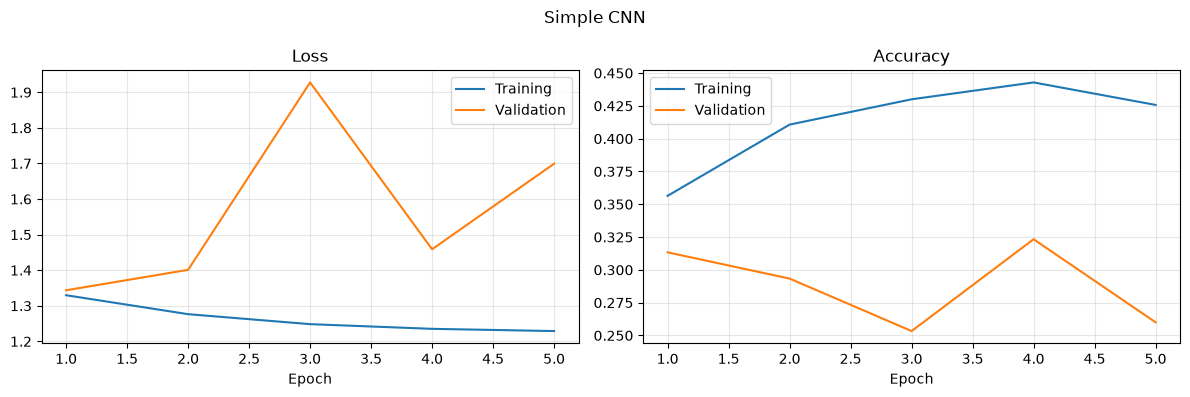

In [9]:
cnn_optimizer = torch.optim.AdamW(simple_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
simple_cnn, cnn_history, cnn_best_val_loss = train_model(
    simple_cnn, cnn_optimizer, epochs=15, name="simple_cnn", patience=4
)
plot_history(cnn_history, "Simple CNN")

## From a CNN to a Residual Neural Network (ResNet)

Adding more layers does not always improve a neural network. In very deep architectures, the signal must pass through many transformations, and the gradient propagated backward during training can become progressively smaller. This phenomenon, known as the **vanishing-gradient problem**, makes it difficult for early layers to learn.

A **Residual Neural Network**, or **ResNet**, mitigates this difficulty with shortcuts called **skip connections**. These shortcuts allow a block's input to move directly across several layers and be added to the result of their transformations.

![ResNet architecture](../../assets/image-19.png)

See [Residual Neural Networks — What You Need to Know](https://datascience.eu/machine-learning/an-overview-of-resnet-and-its-variants/).

The relationship inside a residual block can be represented as:

$$y = F(x) + x$$

Here, `x` is the block input and `F(x)` represents the transformations learned by its internal layers. Instead of learning the entire desired transformation, the block only needs to learn a **residual correction**. If no correction is required, approximating `F(x) = 0` preserves the input through the shortcut.

In addition to facilitating information flow, the shortcut creates a more direct path for gradients during backpropagation. This makes deep-network training more stable, although it does not eliminate every gradient-related problem by itself.

## Transfer learning with ResNet-18

ResNet-18 was originally trained on **ImageNet**, a large collection of natural images organized into 1,000 classes. During that training, the network adjusted millions of parameters to recognize visual patterns useful for distinguishing objects. By using `ResNet18_Weights.DEFAULT`, we load those learned parameters—called **pretrained weights**—instead of starting with random weights.

The learned representations are hierarchical. Early layers generally detect simple and generic visual features such as edges, orientations, contrasts, and textures. Subsequent layers combine these elements into progressively more complex patterns, while the final layers become more specialized in the classes used during the original training.

Reusing these weights is called **transfer learning**. The idea is to use visual knowledge learned from a broad task as a **starting point** for a new task. Compared with training the same architecture from random weights, this often reduces training time and the amount of data required.

There is, however, a domain difference: ImageNet primarily contains color photographs of everyday objects, whereas our dataset contains medical images originally displayed in grayscale. Generic filters from the early layers may therefore remain useful, while more specialized representations may need adaptation during fine-tuning.

### Freeze the backbone and replace the head

We can conceptually divide a ResNet into two parts:

- the **backbone** contains the convolutional blocks responsible for extracting image representations;
- the **classification head** is the final `fc` layer, which transforms those representations into logits for the task's classes.

During the first stage, we set `requires_grad = False` for the backbone parameters. Its pretrained weights then remain fixed during backpropagation and are not updated by the optimizer. The original `fc` layer, built for ImageNet's 1,000 classes, is replaced with a new layer containing `NUM_CLASSES` outputs.

Because the new head is created after the freeze operation, its parameters remain trainable. At this stage, the ResNet acts as a **fixed feature extractor**: the backbone produces representations, and only the head learns how to associate them with the four classes in our dataset. Later, we unfreeze the final backbone block to fine-tune those representations.

In [10]:
resnet18 = models.resnet18(weights=ResNet18_Weights.DEFAULT)
for parameter in resnet18.parameters():
    parameter.requires_grad = False

resnet18.fc = nn.Linear(resnet18.fc.in_features, NUM_CLASSES)
total, trainable = parameter_counts(resnet18)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters in stage 1: {trainable:,}")
print(f"Trainable proportion: {trainable / total:.3%}")

Total parameters: 11,178,564
Trainable parameters in stage 1: 2,052
Trainable proportion: 0.018%


resnet18_head | epoch 01/8 | loss 1.3330/1.2690 | accuracy 36.71%/48.00%
resnet18_head | epoch 02/8 | loss 1.1842/1.2150 | accuracy 49.93%/41.00%
resnet18_head | epoch 03/8 | loss 1.1320/1.1322 | accuracy 53.43%/47.67%
resnet18_head | epoch 04/8 | loss 1.0685/1.0595 | accuracy 55.79%/51.67%
resnet18_head | epoch 05/8 | loss 1.0251/1.0707 | accuracy 58.21%/51.67%
resnet18_head | epoch 06/8 | loss 0.9959/1.0557 | accuracy 60.57%/52.33%
resnet18_head | epoch 07/8 | loss 0.9562/1.0342 | accuracy 62.71%/55.33%
resnet18_head | epoch 08/8 | loss 0.9529/1.0047 | accuracy 61.14%/57.67%


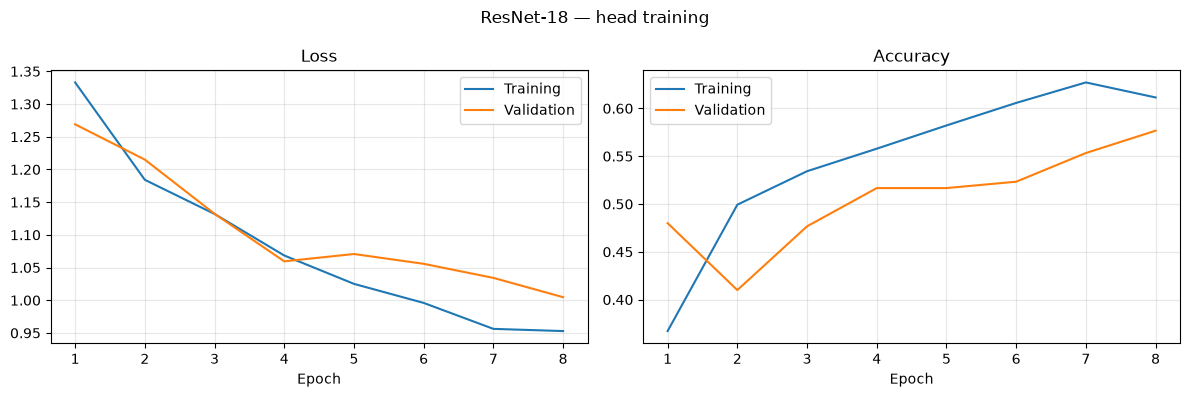

In [11]:
resnet18_head_optimizer = torch.optim.AdamW(
    resnet18.fc.parameters(), lr=1e-3, weight_decay=1e-4
)
resnet18, resnet18_head_history, resnet18_head_best_val_loss = train_model(
    resnet18, resnet18_head_optimizer, epochs=8, name="resnet18_head", patience=3
)
resnet18_head_state = deepcopy(resnet18.state_dict())
plot_history(resnet18_head_history, "ResNet-18 — head training")

### Fine-tune the final block

We now unfreeze only the final residual block (`layer4`). Smaller learning rates are used to adapt high-level representations without abruptly changing the pretrained filters. If validation performance worsens, we retain the state obtained during the previous stage.

resnet18_finetuned | epoch 01/5 | loss 0.7812/0.9517 | accuracy 67.43%/59.00%
resnet18_finetuned | epoch 02/5 | loss 0.4114/0.5567 | accuracy 85.29%/76.67%
resnet18_finetuned | epoch 03/5 | loss 0.2760/0.5627 | accuracy 90.43%/76.00%
resnet18_finetuned | epoch 04/5 | loss 0.1887/0.4686 | accuracy 93.57%/82.33%
resnet18_finetuned | epoch 05/5 | loss 0.1373/0.5131 | accuracy 95.43%/82.00%


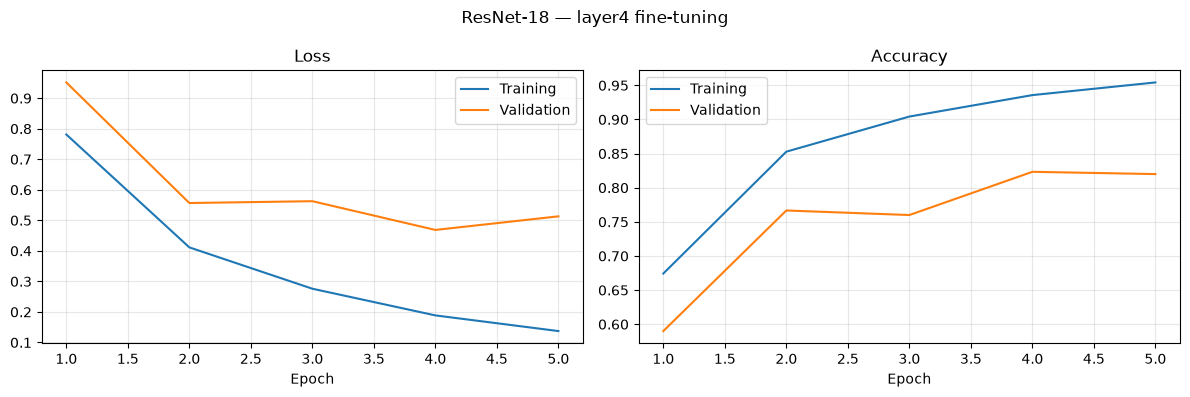

In [12]:
RUN_FINE_TUNING = True

if RUN_FINE_TUNING:
    for parameter in resnet18.layer4.parameters():
        parameter.requires_grad = True

    resnet18_fine_tuning_optimizer = torch.optim.AdamW([
        {"params": resnet18.layer4.parameters(), "lr": 1e-4},
        {"params": resnet18.fc.parameters(), "lr": 5e-4},
    ], weight_decay=1e-4)

    resnet18, resnet18_fine_history, resnet18_fine_best_val_loss = train_model(
        resnet18, resnet18_fine_tuning_optimizer, epochs=5,
        name="resnet18_finetuned", patience=3
    )

    if resnet18_fine_best_val_loss > resnet18_head_best_val_loss:
        print("Fine-tuning did not improve validation; restoring the best head.")
        resnet18.load_state_dict(resnet18_head_state)
    else:
        plot_history(resnet18_fine_history, "ResNet-18 — layer4 fine-tuning")

## Transfer learning with ResNet-50

ResNet-50 is deeper and uses **bottleneck** residual blocks, whereas ResNet-18 uses basic blocks. It has many more parameters and a greater computational cost, but its additional capacity does not guarantee better generalization on this relatively small dataset.

To keep the comparison consistent, we repeat the same protocol: ImageNet weights, initial training of the head only, and fine-tuning of `layer4`, using the same epoch counts, learning rates, and early-stopping rules. ResNet-50 also consumes more memory; if necessary, reduce `BATCH_SIZE` before creating the DataLoaders.

### Freeze the backbone and replace the head

In [13]:
resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)
for parameter in resnet50.parameters():
    parameter.requires_grad = False

resnet50.fc = nn.Linear(resnet50.fc.in_features, NUM_CLASSES)
total, trainable = parameter_counts(resnet50)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters in stage 1: {trainable:,}")
print(f"Trainable proportion: {trainable / total:.3%}")

Total parameters: 23,516,228
Trainable parameters in stage 1: 8,196
Trainable proportion: 0.035%


resnet50_head | epoch 01/8 | loss 1.3038/1.2380 | accuracy 41.14%/48.00%
resnet50_head | epoch 02/8 | loss 1.1626/1.1546 | accuracy 53.43%/49.67%
resnet50_head | epoch 03/8 | loss 1.0799/1.1089 | accuracy 57.93%/52.00%
resnet50_head | epoch 04/8 | loss 1.0179/1.0658 | accuracy 60.64%/53.67%
resnet50_head | epoch 05/8 | loss 0.9841/1.0335 | accuracy 61.14%/54.67%
resnet50_head | epoch 06/8 | loss 0.9382/0.9898 | accuracy 64.29%/59.00%
resnet50_head | epoch 07/8 | loss 0.9255/0.9893 | accuracy 63.86%/57.67%
resnet50_head | epoch 08/8 | loss 0.9010/0.9635 | accuracy 65.93%/58.33%


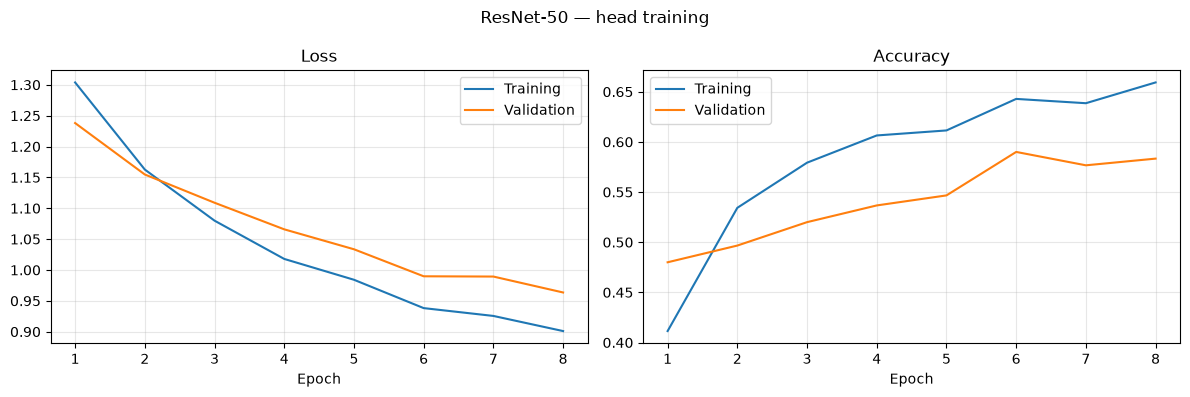

In [14]:
resnet50_head_optimizer = torch.optim.AdamW(
    resnet50.fc.parameters(), lr=1e-3, weight_decay=1e-4
)
resnet50, resnet50_head_history, resnet50_head_best_val_loss = train_model(
    resnet50, resnet50_head_optimizer, epochs=8, name="resnet50_head", patience=3
)
resnet50_head_state = deepcopy(resnet50.state_dict())
plot_history(resnet50_head_history, "ResNet-50 — head training")

### Fine-tune the final block

resnet50_finetuned | epoch 01/5 | loss 0.7831/0.7124 | accuracy 66.64%/68.67%
resnet50_finetuned | epoch 02/5 | loss 0.4361/0.6275 | accuracy 82.64%/73.00%
resnet50_finetuned | epoch 03/5 | loss 0.2681/0.5947 | accuracy 90.64%/75.67%
resnet50_finetuned | epoch 04/5 | loss 0.1749/0.5394 | accuracy 94.21%/78.67%
resnet50_finetuned | epoch 05/5 | loss 0.1242/0.5167 | accuracy 96.07%/80.33%


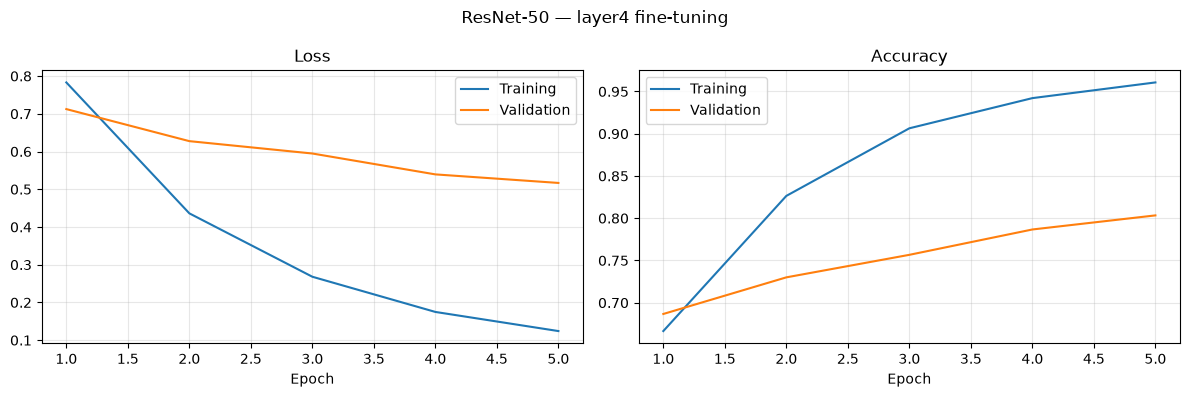

In [15]:
if RUN_FINE_TUNING:
    for parameter in resnet50.layer4.parameters():
        parameter.requires_grad = True

    resnet50_fine_tuning_optimizer = torch.optim.AdamW([
        {"params": resnet50.layer4.parameters(), "lr": 1e-4},
        {"params": resnet50.fc.parameters(), "lr": 5e-4},
    ], weight_decay=1e-4)

    resnet50, resnet50_fine_history, resnet50_fine_best_val_loss = train_model(
        resnet50, resnet50_fine_tuning_optimizer, epochs=5,
        name="resnet50_finetuned", patience=3
    )

    if resnet50_fine_best_val_loss > resnet50_head_best_val_loss:
        print("Fine-tuning did not improve validation; restoring the best head.")
        resnet50.load_state_dict(resnet50_head_state)
    else:
        plot_history(resnet50_fine_history, "ResNet-50 — layer4 fine-tuning")

## Final test evaluation

Only now do the three models receive the test set. In addition to accuracy, we use macro metrics, which give each class equal importance, and balanced accuracy, which remains comparable if the class distribution changes. The total parameter count helps contextualize the cost of each architecture.

In [16]:
def evaluate_model(model, loader):
    model.eval()
    targets, predictions, probabilities = [], [], []

    with torch.no_grad():
        for inputs, batch_targets in loader:
            logits = model(inputs.to(device, non_blocking=True))
            batch_probabilities = torch.softmax(logits, dim=1)
            targets.extend(batch_targets.numpy())
            predictions.extend(batch_probabilities.argmax(dim=1).cpu().numpy())
            probabilities.extend(batch_probabilities.cpu().numpy())

    targets = np.asarray(targets)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    binary_targets = label_binarize(targets, classes=np.arange(NUM_CLASSES))

    metrics = {
        "Accuracy": accuracy_score(targets, predictions),
        "Balanced accuracy": balanced_accuracy_score(targets, predictions),
        "Macro precision": precision_score(targets, predictions, average="macro", zero_division=0),
        "Recall macro": recall_score(targets, predictions, average="macro", zero_division=0),
        "F1 macro": f1_score(targets, predictions, average="macro", zero_division=0),
        "ROC AUC macro": roc_auc_score(
            binary_targets, probabilities, average="macro", multi_class="ovr"
        ),
    }
    return metrics, targets, predictions, probabilities


cnn_metrics, test_targets, cnn_predictions, cnn_probabilities = evaluate_model(
    simple_cnn, test_loader
)
resnet18_metrics, _, resnet18_predictions, resnet18_probabilities = evaluate_model(
    resnet18, test_loader
)
resnet50_metrics, _, resnet50_predictions, resnet50_probabilities = evaluate_model(
    resnet50, test_loader
)

evaluated_models = [
    ("Simple CNN", simple_cnn, cnn_metrics),
    ("ResNet-18", resnet18, resnet18_metrics),
    ("ResNet-50", resnet50, resnet50_metrics),
]
comparison = pd.DataFrame({
    name: {"Parameters (M)": parameter_counts(model)[0] / 1e6, **metrics}
    for name, model, metrics in evaluated_models
}).T
comparison.round(3)

,Parameters (M),Accuracy,Balanced accuracy,Macro precision,Recall macro,F1 macro,ROC AUC macro
Simple CNN,0.024,0.323,0.323,0.500,0.323,0.239,0.667
ResNet-18,11.179,0.817,0.817,0.829,0.817,0.819,0.961
ResNet-50,23.516,0.833,0.833,0.835,0.833,0.834,0.956


In [17]:
predictions_by_model = {
    "Simple CNN": cnn_predictions,
    "ResNet-18": resnet18_predictions,
    "ResNet-50": resnet50_predictions,
}

for name, predictions in predictions_by_model.items():
    print(name)
    print(classification_report(
        test_targets, predictions, target_names=CLASS_NAMES, zero_division=0
    ))

Simple CNN
                    precision    recall  f1-score   support

      Non_Demented       0.30      0.91      0.45        75
Very_Mild_Demented       0.23      0.08      0.12        75
     Mild_Demented       1.00      0.01      0.03        75
 Moderate_Demented       0.47      0.29      0.36        75

          accuracy                           0.32       300
         macro avg       0.50      0.32      0.24       300
      weighted avg       0.50      0.32      0.24       300

ResNet-18
                    precision    recall  f1-score   support

      Non_Demented       0.76      0.85      0.81        75
Very_Mild_Demented       0.67      0.75      0.70        75
     Mild_Demented       0.89      0.73      0.80        75
 Moderate_Demented       1.00      0.93      0.97        75

          accuracy                           0.82       300
         macro avg       0.83      0.82      0.82       300
      weighted avg       0.83      0.82      0.82       300

ResNet-50
   

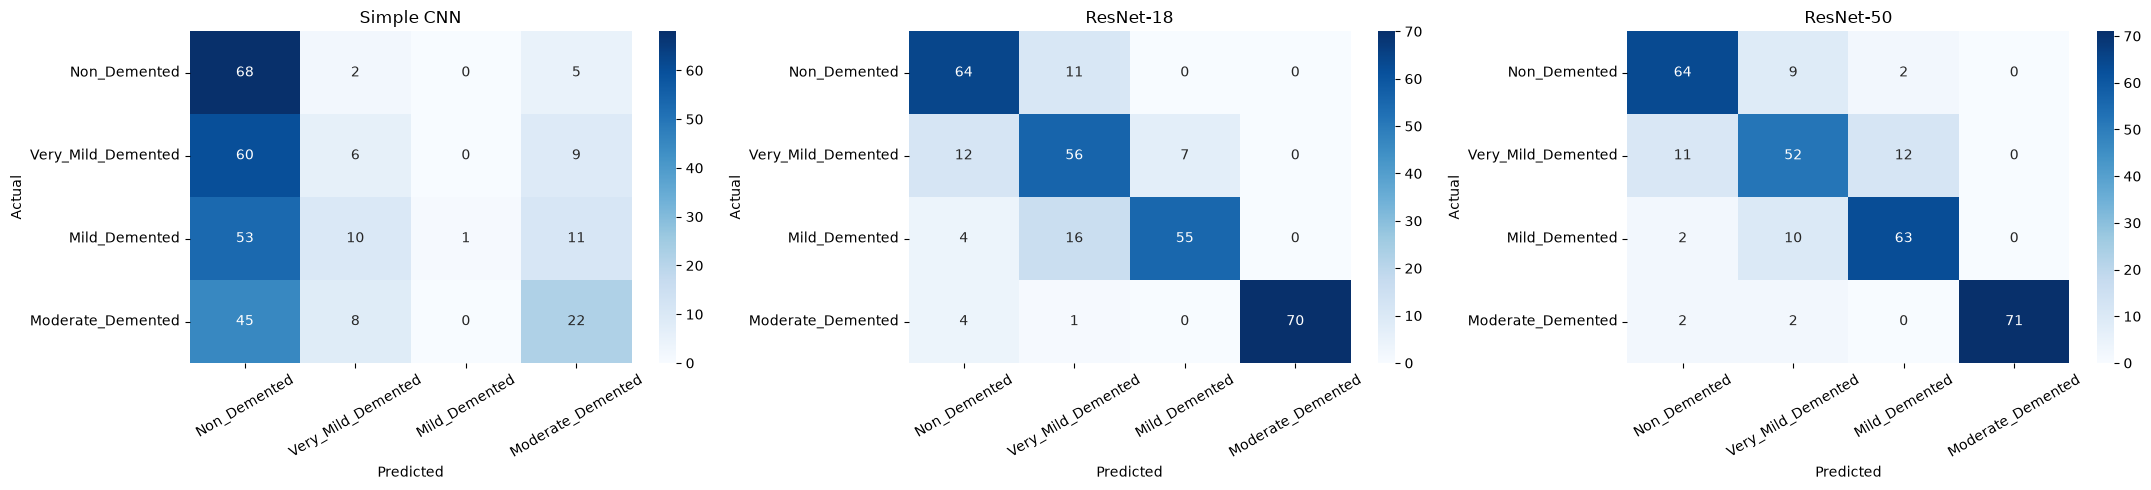

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for axis, (title, predictions) in zip(axes, predictions_by_model.items()):
    matrix = confusion_matrix(test_targets, predictions)
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues", ax=axis,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    axis.set_title(title)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Inference example

The probabilities below are scores produced by the models. They are not calibrated and do not represent clinical confidence.

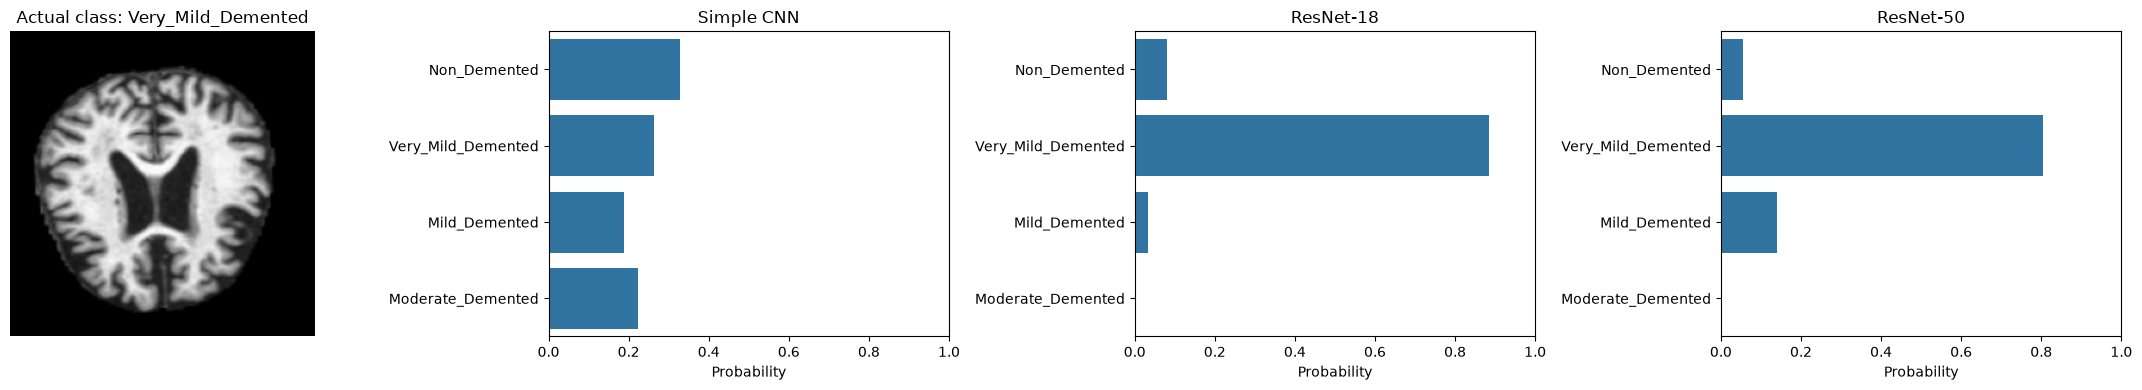

In [19]:
sample_index = 0
sample_record = test_frame.iloc[sample_index]
sample_tensor, sample_target = test_dataset[sample_index]

inference_models = {
    "Simple CNN": simple_cnn,
    "ResNet-18": resnet18,
    "ResNet-50": resnet50,
}
sample_probabilities = {}
with torch.no_grad():
    for name, model in inference_models.items():
        model.eval()
        logits = model(sample_tensor.unsqueeze(0).to(device))
        sample_probabilities[name] = (
            torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        )

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
image = Image.open(DATA_DIR / sample_record["relative_path"]).convert("L")
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"Actual class: {CLASS_NAMES[sample_target.item()]}")
axes[0].axis("off")
for axis, (name, probabilities) in zip(axes[1:], sample_probabilities.items()):
    sns.barplot(x=probabilities, y=CLASS_NAMES, ax=axis)
    axis.set_xlim(0, 1)
    axis.set_title(name)
    axis.set_xlabel("Probability")
plt.tight_layout()
plt.show()